# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** Alex Tomasella

**Date:** March 29th, 2026

---

## Setup: Install and Load Libraries

In [18]:
pip install tensorflow matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [25]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


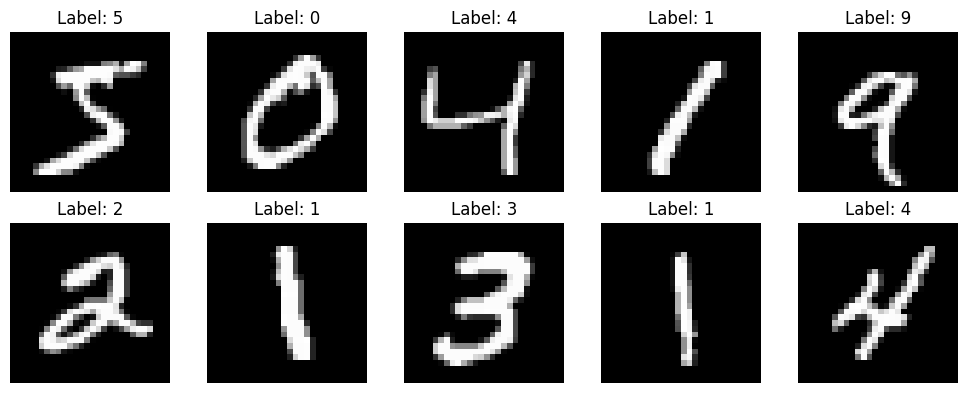

In [26]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [27]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [28]:
# TODO: Build your baseline CNN here
# Architecture:
# - Conv2D layer: 32 filters, 3x3 kernel, ReLU activation, input_shape=(28, 28, 1)
# - MaxPooling2D: 2x2 pool size
# - Conv2D layer: 64 filters, 3x3 kernel, ReLU activation
# - MaxPooling2D: 2x2 pool size
# - Flatten layer
# - Dense layer: 128 nodes, ReLU activation
# - Output layer: 10 nodes (digits 0-9), softmax activation

baseline_cnn = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# TODO: Compile the model
# Use Adam optimizer and sparse_categorical_crossentropy loss
baseline_cnn.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])



# Display model architecture
baseline_cnn.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
print(X_train.shape)

(60000, 28, 28)


In [30]:
# Record training time
print("\nTraining baseline CNN...")
start_time = time.time()

# TODO: Fit the model and store history
history = baseline_cnn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)  # Replace with actual model fitting

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test, y_test, verbose=0)  # Replace with actual evaluation

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)


Training baseline CNN...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9158 - loss: 0.7289 - val_accuracy: 0.9704 - val_loss: 0.1000
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9801 - loss: 0.0640 - val_accuracy: 0.9804 - val_loss: 0.0651
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9880 - loss: 0.0396 - val_accuracy: 0.9826 - val_loss: 0.0584
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9907 - loss: 0.0282 - val_accuracy: 0.9851 - val_loss: 0.0583
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9935 - loss: 0.0195 - val_accuracy: 0.9837 - val_loss: 0.0634
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9920 - loss: 0.0235 - val_accuracy: 0.9817 - val_loss: 0.0702
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9938 - loss: 0.0180 - val_accuracy: 0.9844 - val_loss: 0.0672
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.995

In [32]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

---
## Step 3: Experiment with Filter Counts

In [36]:
# TODO: Build and train CNN with FEWER filters (16, 32)
# Keep all other architecture elements the same as baseline
fewer_filters_model = keras.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

print("Training CNN with fewer filters (16, 32)...")
# TODO: Build, compile, and train model
# Record validation accuracy
fewer_filters_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

start_time = time.time()

# TODO: Fit the model and store history
history = fewer_filters_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)  # Replace with actual model fitting

fewer_filters_time = time.time() - start_time

# TODO: Evaluate on test set
fewer_filters_test_loss, fewer_filters_test_acc = fewer_filters_model.evaluate(X_test, y_test, verbose=0)

test_loss, test_accuracy = fewer_filters_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}") 
print(f"Test Loss: {test_loss:.4f}")



Training CNN with fewer filters (16, 32)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9016 - loss: 0.7185 - val_accuracy: 0.9642 - val_loss: 0.1211
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9757 - loss: 0.0802 - val_accuracy: 0.9802 - val_loss: 0.0733
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9859 - loss: 0.0447 - val_accuracy: 0.9818 - val_loss: 0.0684
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9905 - loss: 0.0290 - val_accuracy: 0.9812 - val_loss: 0.0682
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9939 - loss: 0.0199 - val_accuracy: 0.9769 - val_loss: 0.0920
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9927 - loss: 0.0221 - val_accuracy: 0.9844 - val_loss: 0.0620
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9948 - loss: 0.0147 - val_accuracy: 0.9834 - val_loss: 0.0675
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accu

In [37]:
# TODO: Build and train CNN with MORE filters (64, 128)
# Keep all other architecture elements the same as baseline
more_filters_model = keras.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

print("Training CNN with more filters (64, 128)...")
# TODO: Build, compile, and train model
# Record validation accuracy
more_filters_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

start_time = time.time()

# TODO: Fit the model and store history
history = more_filters_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)  # Replace with actual model fitting

more_filters_time = time.time() - start_time

# TODO: Evaluate on test set
more_filters_test_loss, more_filters_test_acc = more_filters_model.evaluate(X_test, y_test, verbose=0)

test_loss, test_accuracy = more_filters_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}") 
print(f"Test Loss: {test_loss:.4f}")



Training CNN with more filters (64, 128)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9153 - loss: 0.9739 - val_accuracy: 0.9773 - val_loss: 0.0736
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.9832 - loss: 0.0541 - val_accuracy: 0.9827 - val_loss: 0.0608
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9870 - loss: 0.0400 - val_accuracy: 0.9831 - val_loss: 0.0597
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.9903 - loss: 0.0288 - val_accuracy: 0.9834 - val_loss: 0.0624
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.9920 - loss: 0.0232 - val_accuracy: 0.9843 - val_loss: 0.0628
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.9935 - loss: 0.0187 - val_accuracy: 0.9852 - val_loss: 0.0611
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9934 - loss: 0.0194 - val_accuracy: 0.9854 - val_loss: 0.0562
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 44

### Analysis: Filter Count Effects

**TODO: Write 2-3 sentences answering:**
- How does increasing filter count affect performance?
- At what point do you see diminishing returns or overfitting?

Increasing the number of filters improved the models accuracy because each filter is kind of like a pattern detector. You see diminsihing results when you up the amount of filters and get a very small increase of accuracy.

---
## Step 4: Experiment with Kernel Sizes

In [38]:
# TODO: Build and train CNN with MEDIUM kernels (5x5 for both layers)
# Keep filter counts at baseline (32, 64)
larger_kernals_model = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

print("Training CNN with 5x5 kernels...")
# TODO: Build, compile, and train model
# Record validation accuracy

larger_kernals_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
start_time = time.time()

# TODO: Fit the model and store history
history = larger_kernals_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)  # Replace with actual model fitting

larger_kernals_time = time.time() - start_time

# TODO: Evaluate on test set
larger_kernals_test_loss, larger_kernals_test_acc = larger_kernals_model.evaluate(X_test, y_test, verbose=0)

test_loss, test_accuracy = larger_kernals_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}") 
print(f"Test Loss: {test_loss:.4f}")


Training CNN with 5x5 kernels...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9067 - loss: 0.7223 - val_accuracy: 0.9655 - val_loss: 0.1117
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9782 - loss: 0.0743 - val_accuracy: 0.9747 - val_loss: 0.0830
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9844 - loss: 0.0496 - val_accuracy: 0.9814 - val_loss: 0.0628
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9899 - loss: 0.0317 - val_accuracy: 0.9828 - val_loss: 0.0611
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9911 - loss: 0.0268 - val_accuracy: 0.9856 - val_loss: 0.0514
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9926 - loss: 0.0232 - val_accuracy: 0.9810 - val_loss: 0.0694
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9915 - loss: 0.0266 - val_accuracy: 0.9833 - val_loss: 0.0633
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy:

In [39]:
# TODO: Build and train CNN with MIXED kernels (5x5 first layer, 3x3 second layer)
# Keep filter counts at baseline (32, 64)
mixed_kernals_model = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

print("Training CNN with mixed kernels (5x5, 3x3)...")
# TODO: Build, compile, and train model
# Record validation accuracy
mixed_kernals_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
start_time = time.time()

# TODO: Fit the model and store history
history = mixed_kernals_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)  # Replace with actual model fitting

mixed_kernals_time = time.time() - start_time

# TODO: Evaluate on test set
mixed_kernals_test_loss, mixed_kernals_test_acc = mixed_kernals_model.evaluate(X_test, y_test, verbose=0)

test_loss, test_accuracy = mixed_kernals_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}") 
print(f"Test Loss: {test_loss:.4f}")

Training CNN with mixed kernels (5x5, 3x3)...
Epoch 1/10


c:\Users\aatra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9113 - loss: 0.9521 - val_accuracy: 0.9769 - val_loss: 0.0838
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9819 - loss: 0.0594 - val_accuracy: 0.9826 - val_loss: 0.0627
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9888 - loss: 0.0367 - val_accuracy: 0.9836 - val_loss: 0.0569
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9916 - loss: 0.0263 - val_accuracy: 0.9829 - val_loss: 0.0573
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9932 - loss: 0.0218 - val_accuracy: 0.9849 - val_loss: 0.0581
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9935 - loss: 0.0189 - val_accuracy: 0.9843 - val_loss: 0.0694
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9943 - loss: 0.0179 - val_accuracy: 0.9848 - val_loss: 0.0616
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9945 - loss: 0.0166 - val_accuracy: 0.985

### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

Smaller kernels focus on the smaller details and the larger kernels focus on the bigger patterns. In this assignment, the bigger kernel set up performed better. This could because we the data contains larger images which larger kernels do better. 

---
## Step 5: Train Your Best Architecture and Visualize Learning

In [54]:
# TODO: Based on your experiments, build your best-performing CNN architecture
# Train for 15 epochs with 20% validation split

best_cnn_model = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

print("Training best CNN architecture...")
best_cnn_time = time.time() - start_time


# TODO: Build, compile, and train your best model
# Store the training history
best_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

best_history = best_cnn_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# TODO: Evaluate on test set
test_loss, best_test_accuracy = best_cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {best_test_accuracy:.4f}") 
print(f"Test Loss: {test_loss:.4f}")


Training best CNN architecture...
Epoch 1/15


c:\Users\aatra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9219 - loss: 0.6568 - val_accuracy: 0.9716 - val_loss: 0.0894
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9789 - loss: 0.0669 - val_accuracy: 0.9785 - val_loss: 0.0736
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9859 - loss: 0.0435 - val_accuracy: 0.9814 - val_loss: 0.0642
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9901 - loss: 0.0310 - val_accuracy: 0.9825 - val_loss: 0.0622
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9918 - loss: 0.0251 - val_accuracy: 0.9827 - val_loss: 0.0644
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9931 - loss: 0.0201 - val_accuracy: 0.9818 - val_loss: 0.0705
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9937 - loss: 0.0185 - val_accuracy: 0.9845 - val_loss: 0.0750
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9935 - loss: 0.0205 - val_accuracy: 0.98

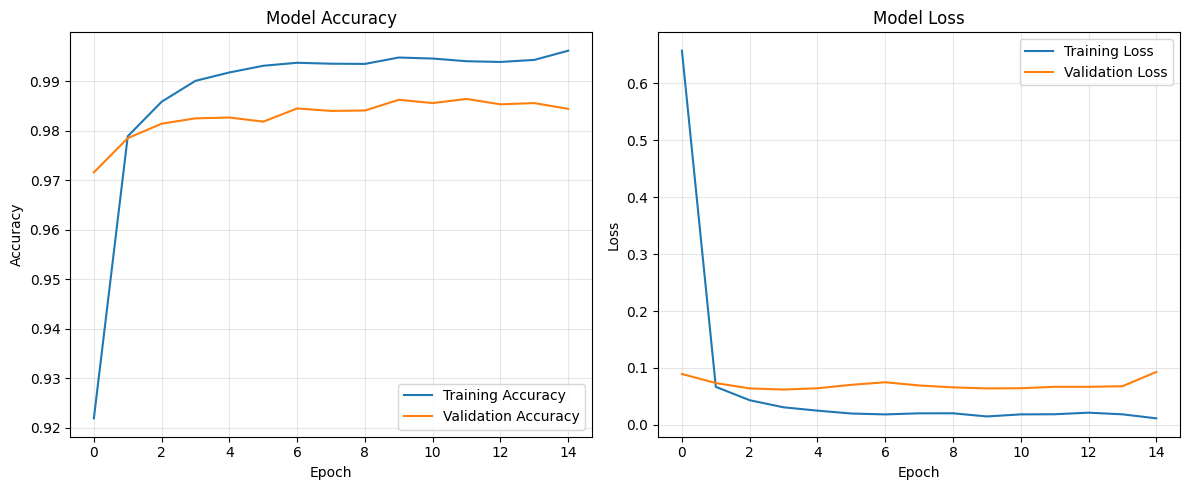

In [55]:
# TODO: Create accuracy plot (training vs validation accuracy over epochs)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
# TODO: Plot training and validation accuracy
plt.plot(best_history.history['accuracy'], label='Training Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
# TODO: Plot training and validation loss
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [47]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [48]:
# TODO: Build feedforward network
# Architecture:
# - Input: 784 features (flattened 28x28 image)
# - Dense layer: 128 nodes, ReLU activation
# - Dense layer: 64 nodes, ReLU activation
# - Output layer: 10 nodes, softmax activation

feedforward_nn = keras.Sequential([
    # TODO: Add layers here
    layers.Flatten(input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# TODO: Compile the model
feedforward_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

feedforward_nn.summary()

c:\Users\aatra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_19 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Record training time
print("Training feedforward network...")
start_time = time.time()

# TODO: Train feedforward network for 10 epochs
# Fit the model
feedforward_history = feedforward_nn.fit(
    X_train_flat,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


# Record training time
feedforward_time = time.time() - start_time

# TODO: Evaluate on test set
feedforward_test_loss, feedforward_test_acc = feedforward_nn.evaluate(X_test_flat, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}") 
print(f"Test Loss: {test_loss:.4f}")

Training feedforward network...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9946 - loss: 0.0184 - val_accuracy: 0.9742 - val_loss: 0.1096
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9958 - loss: 0.0145 - val_accuracy: 0.9743 - val_loss: 0.0964
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9955 - loss: 0.0141 - val_accuracy: 0.9744 - val_loss: 0.1063
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9963 - loss: 0.0123 - val_accuracy: 0.9758 - val_loss: 0.1014
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9968 - loss: 0.0106 - val_accuracy: 0.9734 - val_loss: 0.1144
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9966 - loss: 0.0113 - val_accuracy: 0.9760 - val_loss: 0.1030
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9976 - loss: 0.0083 - val_accuracy: 0.9742 - val_loss: 0.1173
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9965 -

In [59]:
# TODO: Create comparison table

comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        # TODO: Fill in architecture details
        "Conv2D(32, (3, 3)) -> MaxPooling2D((2, 2)) -> Conv2D(64, (3, 3)) -> MaxPooling2D((2, 2)) -> Flatten() -> Dense(128) -> Dense(10)",
        "Conv2D(32, (5, 5)) -> MaxPooling2D((2, 2)) -> Conv2D(64, (3, 3)) -> MaxPooling2D((2, 2)) -> Flatten() -> Dense(128) -> Dense(10)",
        "Dense(128) -> Dense(64) -> Dense(10)"
        
    ],
    'Test Accuracy': [
        # TODO: Fill in test accuracies
        baseline_test_acc,
        best_test_accuracy,
        feedforward_test_acc
    ],
    'Training Time (s)': [
        # TODO: Fill in training times
        baseline_time,
        best_cnn_time,
        feedforward_time
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model                                                                                                                     Architecture  Test Accuracy  Training Time (s)
  Baseline CNN Conv2D(32, (3, 3)) -> MaxPooling2D((2, 2)) -> Conv2D(64, (3, 3)) -> MaxPooling2D((2, 2)) -> Flatten() -> Dense(128) -> Dense(10)         0.9861          63.993294
      Best CNN Conv2D(32, (5, 5)) -> MaxPooling2D((2, 2)) -> Conv2D(64, (3, 3)) -> MaxPooling2D((2, 2)) -> Flatten() -> Dense(128) -> Dense(10)         0.9861         339.673221
Feedforward NN                                                                                             Dense(128) -> Dense(64) -> Dense(10)         0.9746          11.799917


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

My best CNN worked better than the feedforward network for this data set. CNN's mspatial awarnes leads to better performance because the feedforward netowrk treats some pixels as equally related as others. 

---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

I do not believe CNNs or RNNs would be super beneficial for me to use. This is because my data is fairly well structured and does not contain any images but rather healthcare data with strings and numbers. My project data does use tabular data. It has things such as age, medical condition, and billing amount which can be used in traditional ML models to find relationships  within the variables. 

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.